# Concordance with bulk Hi-C (Fig S8)

Part of the **[Fig. 1 chapter](fig1.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{hic_dir}metadata.tsv'`  ·  _metadata_
- `f'{loop_dir}merged_loop_subtype.bedpe'`  ·  _loop calls_
- `f'{hic_dir}../merged_loop_raw.feather'`  ·  _loop calls_
- `f'{hic_dir}../merged_loop_norm.feather'`  ·  _loop calls_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{hic_dir}../merged_loop.fdr.hdf'`  ·  _loop calls_
- `f'{hic_dir}../loop_Q.hdf'`  ·  _loop calls_
- `f'{hic_dir}../loop_E.hdf'`  ·  _loop calls_
- `f'compare_bulkhic/Ecorr_subtype_ENCODE.hdf'`  ·  _ext: ENCODE_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import os
import glob
import cooler
import pandas as pd
import numpy as np
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")



In [3]:
indir = f'{ENTEX_ROOT}/'
loop_dir = f'{indir}loop/subtype/'
hic_dir = f'{indir}bulk_HiC/data/'


In [4]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [5]:
from scipy.stats import zscore

def dist_norm(A, cap=5, max_dist=5000000, res=10000):
    n_diag = max_dist // res + 1
    E = np.zeros(A.shape, dtype=float)
    mask = np.zeros(E.shape, dtype=bool)
    row, col = np.diag_indices(E.shape[0])
    mask[row, col] = True
    for i in range(1, n_diag):
        mask[row[:-i], col[i:]] = True

    E[row, col] = 0
    for i in range(1, n_diag):
        tmp = A.diagonal(i).copy()
        tmp_filter = (tmp > 0)
        tmp2 = tmp[tmp_filter]
        if len(tmp2) == 0:
            E[row[:-i], col[i:]] = 0
        else:
            cutoff = np.percentile(tmp2, 99)
            tmp2 = np.where(tmp2 < cutoff, tmp2, cutoff)
            tmp2 = zscore(tmp2)
            tmp2[np.isnan(tmp2)] = 0
            tmp2 = np.clip(tmp2, a_min=-cap, a_max=cap)
            tmp[~tmp_filter] = tmp2.min()
            tmp[tmp_filter] = tmp2.copy()
            E[row[:-i], col[i:]] = tmp.copy()
    return E


In [6]:
hic_list = pd.read_csv(f'{hic_dir}metadata.tsv', sep='\t', header=0, index_col=0)
hic_list

In [7]:
res = 10000
loop_all = pd.read_csv(f'{loop_dir}merged_loop_subtype.bedpe', header=None, index_col=None, sep='\t')


In [8]:
loop_A = pd.DataFrame(index=loop_all.index, columns=hic_list.index[hic_list['File format']=='hic'])
loop_E = loop_A.copy()

loop_all = {chrom:loop_all.loc[loop_all[0]==chrom, [1,4]] // res for chrom in chrom_sizes.index[:22]}


In [9]:
from scipy.sparse import csr_matrix
import hicstraw

def load_hic(hic_path, chrom, res=10000):
    data = hicstraw.straw("observed", "VC_SQRT", hic_path, chrom, chrom, "BP", res)
    nbins = (chrom_sizes.loc[chrom] // res) + 1
    idx, idy, counts = [], [], []
    for xx in data:
        idx.append(xx.binX // res)
        idy.append(xx.binY // res)
        counts.append(xx.counts)
    A = csr_matrix((counts, (idx, idy)), shape=(nbins, nbins)).toarray()
    return A


In [10]:
def load_loop_values(hic_path, chrom, res=10000):
    A = load_hic(hic_path, chrom)
    E = dist_norm(A)
    idx, idy = loop_all[chrom].values.T
    return [A[idx, idy], E[idx, idy]]


In [11]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 24
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for hic_file in hic_list.loc[hic_list['File format'] == 'hic'].index:
        for chrom in chrom_sizes.index[:22]:
            future = executor.submit(
                load_loop_values,
                hic_path=f'{hic_dir}{hic_file}.hic',
                chrom=chrom,
            )
            futures[future] = [chrom, hic_file]

    for future in as_completed(futures):
        tmp = future.result()
        chrom, hic_file = futures[future] 
        loop_A.loc[loop_all[chrom].index, hic_file] = tmp[0].copy()
        loop_E.loc[loop_all[chrom].index, hic_file] = tmp[1].copy()
        print(f'{chrom} {hic_file} finished')
        

In [12]:
loop_A = pd.read_feather(f'{hic_dir}../merged_loop_raw.feather')
loop_E = pd.read_feather(f'{hic_dir}../merged_loop_norm.feather')


In [13]:
loop_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
loop_all = pd.read_csv(f'{loop_dir}merged_loop_subtype.bedpe', header=None, index_col=None, sep='\t')
loop_all.index = loop_all[0].astype(str) + '-' + (loop_all[1] // res).astype(str) + '-' + (loop_all[4] // res).astype(str)


In [14]:
loop_fdr = pd.read_hdf(f'{hic_dir}../merged_loop.fdr.hdf')
loop_fdr.index = loop_fdr[0].astype(str) + '-' + (loop_fdr[1] // res).astype(str) + '-' + (loop_fdr[4] // res).astype(str)
loop_fdr


In [15]:
loop_A = pd.read_feather(f'{hic_dir}../merged_loop_raw.feather')
loop_N = pd.read_feather(f'{hic_dir}../merged_loop_norm.feather')


In [16]:
loop_Q = pd.read_hdf(f'{hic_dir}../loop_Q.hdf')
loop_E = pd.read_hdf(f'{hic_dir}../loop_E.hdf')


In [17]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


In [18]:
selp = ((zscore(loop_fdr['Qanova'])>thres2) & (zscore(loop_fdr['Tanova'])>thres2))
print(selp.sum())

In [19]:
loop_A.index = loop_all.index.copy()
loop_N.index = loop_all.index.copy()
loop_Q.index = loop_fdr.index.copy()
loop_E.index = loop_fdr.index.copy()


In [20]:
selp = selp.index[selp]


In [21]:
from sklearn.metrics import pairwise_distances
# selp = stdev.nlargest(100000).index
# dist = pairwise_distances(loop_A.loc[selp].T, loop_Q.loc[selp].T, metric='correlation')
dist = pairwise_distances(loop_N.loc[selp].T, loop_E.loc[selp].T, metric='correlation')
dist = pd.DataFrame(dist, 
                    index=loop_A.columns.map(hic_list['Biosample term name']), 
                    columns=loop_Q.columns.map(loop_meta['celltype_L2_both_abbr']))
dist.to_hdf(f'compare_bulkhic/Ecorr_subtype_ENCODE.hdf', key='data')


In [22]:
dist = pd.read_hdf(f'compare_bulkhic/Ecorr_subtype_ENCODE.hdf', key='data')
cg = sns.clustermap(1-dist, z_score=0, xticklabels=1, yticklabels=1, figsize=(36, 18), cmap='cividis_r', vmin=1, vmax=3)
rorder = cg.dendrogram_row.reordered_ind
corder = cg.dendrogram_col.reordered_ind


In [23]:
# dist = dist.iloc[rorder[::-1], :]
# bestbulk = np.argmin(dist, axis=0)
# dist = dist.iloc[:, np.argsort(bestbulk)]

dist = dist.iloc[:, corder[::-1]]
bestbulk = np.argmin(dist, axis=1)
dist = dist.iloc[np.argsort(bestbulk), :]


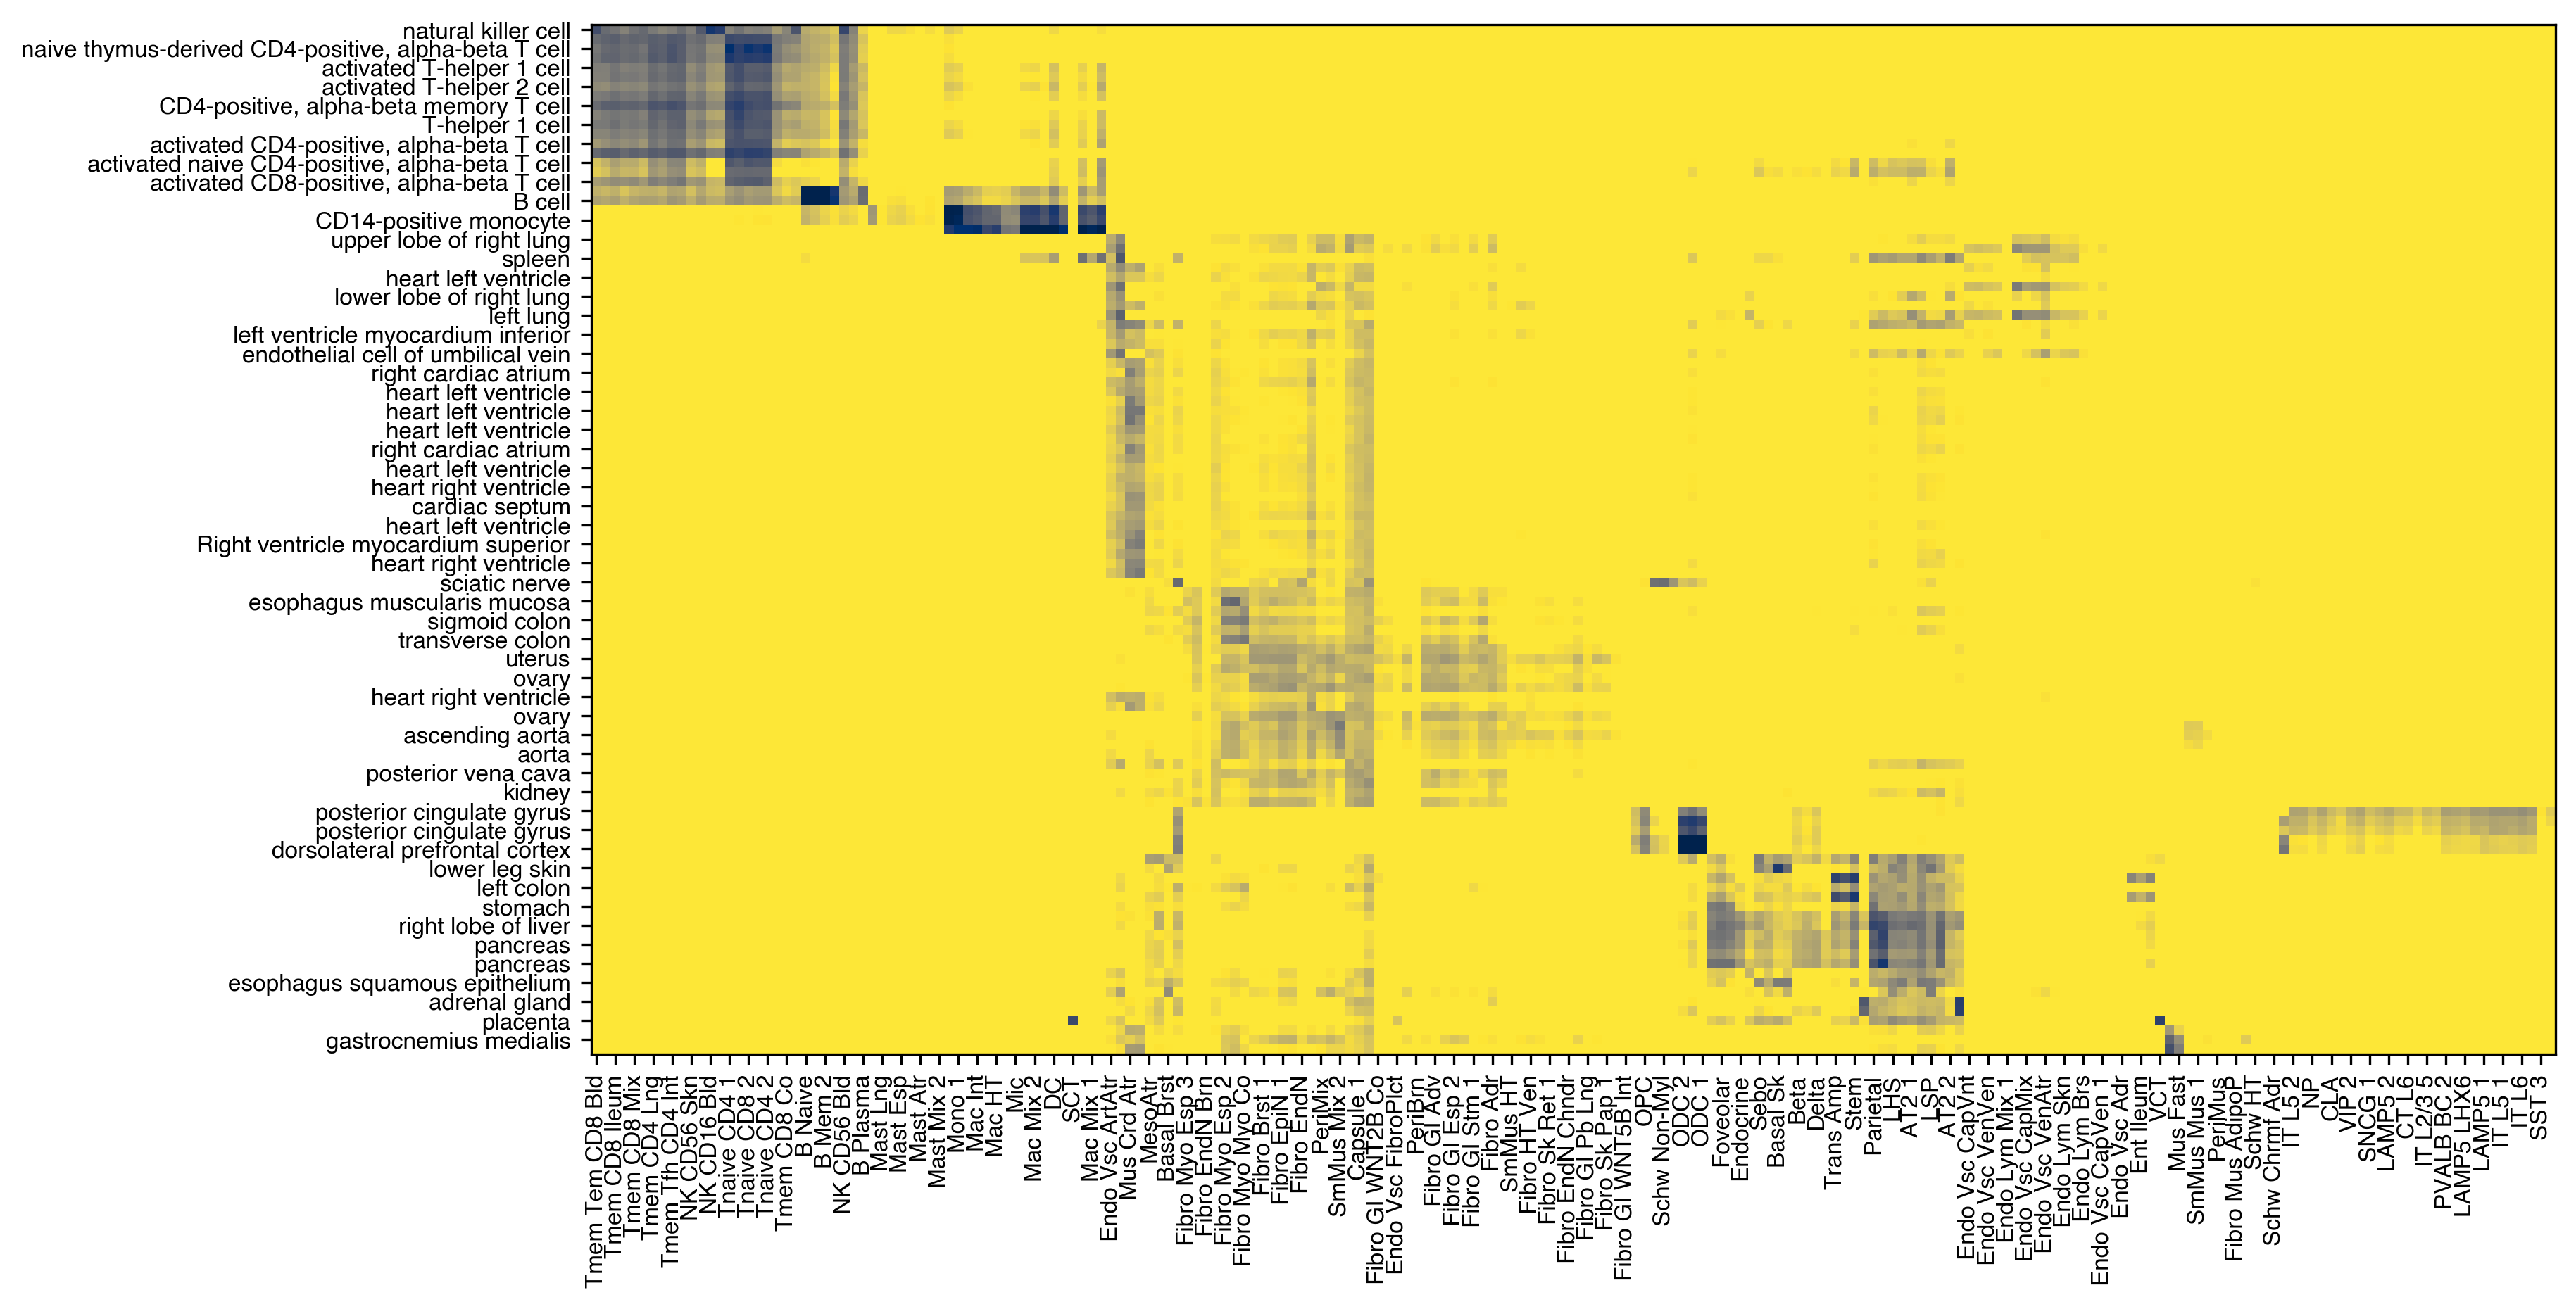

In [24]:
fig, ax = plt.subplots(figsize=(12,12), dpi=300)
ax.imshow(zscore(1-dist, axis=1), vmin=1, vmax=3, cmap='cividis_r')
xticks = np.arange(0, dist.shape[1], 2)
ax.set_xticks(xticks)
ax.set_xticklabels(dist.columns[xticks], fontsize=8, rotation=90)
yticks = np.arange(0, dist.shape[0], 2)
ax.set_yticks(yticks)
ax.set_yticklabels(dist.index[yticks], fontsize=8, rotation=0)
fig.savefig('compare_bulkhic/Ecorr_subtype_ENCODE.pdf', transparent=True)
